In [1]:
import numpy as np 
from quspin.operators import hamiltonian, quantum_operator
from quspin.basis import spin_basis_1d
from quspin.tools.measurements import ent_entropy
import matplotlib.pyplot as plt

In [2]:
#define the model parameters
L=14
alpha=0.3
beta=0.5
lam1=1.0
k=2

Starting from

$$
H^{(2)}_s
=
\sum_{a,j}
\alpha_{j,a}
\left[
e^{-\beta_a(X_j+X_{j+2})}
-
Z_jX_{j+1}Z_{j+2}
\right],
$$

we use the fact that $X_j$ and $X_{j+2}$ commute,

$$
e^{-\beta_a(X_j+X_{j+2})}
=
e^{-\beta_a X_j}e^{-\beta_a X_{j+2}}.
$$

Using

$$
e^{-\beta_a X}
=
\cosh\beta_a-\sinh\beta_a X,
$$

we obtain

$$
\begin{aligned}
e^{-\beta_a(X_j+X_{j+2})}
&=
\left(
\cosh\beta_a-\sinh\beta_a X_j
\right)
\left(
\cosh\beta_a-\sinh\beta_a X_{j+2}
\right)
\\
&=
\cosh^2\beta_a
-\sinh\beta_a\cosh\beta_a\,X_j
-\sinh\beta_a\cosh\beta_a\,X_{j+2}
+\sinh^2\beta_a\,X_jX_{j+2}.
\end{aligned}
$$

Therefore,

$$
\begin{aligned}
H^{(2)}_s
=
\sum_{a,j}
\alpha_{j,a}
\Big[
&\cosh^2\beta_a
-\sinh\beta_a\cosh\beta_a\,X_j
-\sinh\beta_a\cosh\beta_a\,X_{j+2}
\\
&+\sinh^2\beta_a\,X_jX_{j+2}
-Z_jX_{j+1}Z_{j+2}
\Big].
\end{aligned}
$$

### Alternating coupling for $k=2$

For the $k=2$ chain, the coupling $\alpha_j$ is defined as

$$
\alpha_j^{(a)}
=
|\alpha|
+
(-1)^{\frac{j-a}{2}},
\qquad
|\alpha|<1,
\qquad
a=0,1.
$$

The index $a$ specifies the sublattice on which the alternating pattern is
defined. For $a=0$, $j$ takes even values, while for $a=1$, $j$ takes odd
values.

For $a=0$,

$$
\alpha_j^{(0)}
=
|\alpha|
+
(-1)^{j/2},
\qquad
j=0,2,4,\ldots
$$

and therefore

$$
\alpha_0^{(0)}=|\alpha|+1,
\qquad
\alpha_2^{(0)}=|\alpha|-1,
\qquad
\alpha_4^{(0)}=|\alpha|+1,
\qquad \ldots
$$

Similarly, for $a=1$,

$$
\alpha_j^{(1)}
=
|\alpha|
+
(-1)^{(j-1)/2},
\qquad
j=1,3,5,\ldots
$$

giving

$$
\alpha_1^{(1)}=|\alpha|+1,
\qquad
\alpha_3^{(1)}=|\alpha|-1,
\qquad
\alpha_5^{(1)}=|\alpha|+1,
\qquad \ldots
$$

Thus, the coupling alternates between the two values

$$
\alpha_+ = |\alpha|+1,
\qquad
\alpha_- = |\alpha|-1.
$$

The parameter $a$ determines which set of sites carries the first value
$\alpha_+$. In particular,

$$
\begin{array}{c|cccc}
j & 0 & 2 & 4 & 6 \\ \hline
a=0 & \alpha_+ & \alpha_- & \alpha_+ & \alpha_-
\end{array}
$$

while

$$
\begin{array}{c|cccc}
j & 1 & 3 & 5 & 7 \\ \hline
a=1 & \alpha_+ & \alpha_- & \alpha_+ & \alpha_-
\end{array}
$$

This definition is different from the simpler modulation
$\alpha+(-1)^j$. In the present case, the alternating structure has period
$4$ in the original site index $j$, with the two values $\alpha_+$ and
$\alpha_-$ appearing on a fixed parity sublattice.

In [3]:
# ----- Basis -----
basis_even = spin_basis_1d(L, pauli=True, zblock=1)  # Pauli convention
basis_odd = spin_basis_1d(L, pauli=True, zblock=-1)  # Pauli convention

bases=[basis_even,basis_odd]
full_basis=spin_basis_1d(L, pauli=True)

In [4]:
def alpha_aj(j, alpha, a):
    return alpha + (-1)**((j - a)//2)

In [5]:
def add_block(SL, beta, L, alpha, a, defect_site=None):
    c = np.cosh(beta)
    s = np.sinh(beta)

    a0   = []
    axL  = []
    axR  = []
    axx  = []
    azxz = []

    for j in SL:

        jm = (j - 1) % L
        jp = (j + 1) % L

        coeff = lam1 * alpha_aj(j, alpha, a)

        # Normal cluster term:
        # - alpha_{j,a} Z_{j-1} X_j Z_{j+1}
        cluster_coeff = -coeff

        # One defect: flip only the cluster term at j = defect_site
        if defect_site is not None and j == defect_site:
            cluster_coeff = +coeff

        # Expansion of exp[-beta (X_{j-1} + X_{j+1})]
        a0.append([coeff * c**2, j])

        axL.append([-coeff * s * c, jm])
        axR.append([-coeff * s * c, jp])

        axx.append([coeff * s**2, jm, jp])

        # Cluster term
        azxz.append([cluster_coeff, jm, j, jp])

    return [
        ['I',   a0],
        ['x',   axL],
        ['x',   axR],
        ['xx',  axx],
        ['zxz', azxz],
    ]

In [6]:
SL1 = [j for j in range(L) if j % 2 == 0]  # a = 0
SL2 = [j for j in range(L) if j % 2 == 1]  # a = 1

# Choose subsystem (half-chain here)
subsystem_size = L // 2
subsys_A = list(range(subsystem_size))

full_energies = []
full_states   = []
full_entropies = []

for basis in bases:

    static_spin = []

    # a = 0 sector: j = 0, 2, 4, ..., L-2
    # No defect in this sector
    static_spin += add_block(
        SL1,
        beta,
        L,
        alpha,
        a=0,
        defect_site=None
    )

    # a = 1 sector: j = 1, 3, 5, ..., L-1
    # One defect at j = 5
    static_spin += add_block(
        SL2,
        beta,
        L,
        alpha,
        a=1,
        defect_site=7
    )

    dynamic_spin = []

    # Build Hamiltonian
    H = hamiltonian(
        static_spin,
        dynamic_spin,
        basis=basis,
        check_symm=False,
        dtype=np.complex128
    )

    # Diagonalize
    energies, states = H.eigh()

    # Compute entanglement entropies
    entropies = np.zeros(states.shape[1])

    for i, state in enumerate(states.T):
        entropy_dict = ent_entropy(
            state.T,
            basis=basis,
            chain_subsys=subsys_A,
            density=False
        )

        entropies[i] = entropy_dict['Sent_A']

    # Project to full basis
    full_s = basis.project_from(states, full_basis)

    full_states.append(full_s)
    full_energies.append(energies)
    full_entropies.append(entropies)

Hermiticity check passed!
Hermiticity check passed!


In [ ]:
from scipy.sparse import hstack

full_spec = np.concatenate((full_energies[0], full_energies[1]))
full_vecs = hstack([full_states[0], full_states[1]])
full_entropies_all = np.concatenate((full_entropies[0], full_entropies[1]))

In [ ]:
#sort everything
sorted_indices=np.argsort(full_spec)
sorted_entropies=full_entropies_all[sorted_indices]
sorted_energies=full_spec[sorted_indices]

In [9]:
#Plotting entropy with the symmetry breaking perturbations. Set the style of the plot
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
})

In [26]:
tol=1e-12
scars_idx=np.where((sorted_entropies<3) & (np.abs(sorted_energies)<tol))[0]
scars_idx

array([856])

In [ ]:
# For github only, to run this cell in local folder remove the ../data/k2/
data = np.load(
    "../data/k2/quspin_simulation_data_k2_chain_1_defects.npz",
    allow_pickle=True
)

sorted_indices = data["sorted_indices"]
full_energies = data["energies"].tolist()
full_entropies = data["entropies"].tolist()
L = int(data["L"])
alpha = float(data["alpha"])
beta = float(data["beta"])

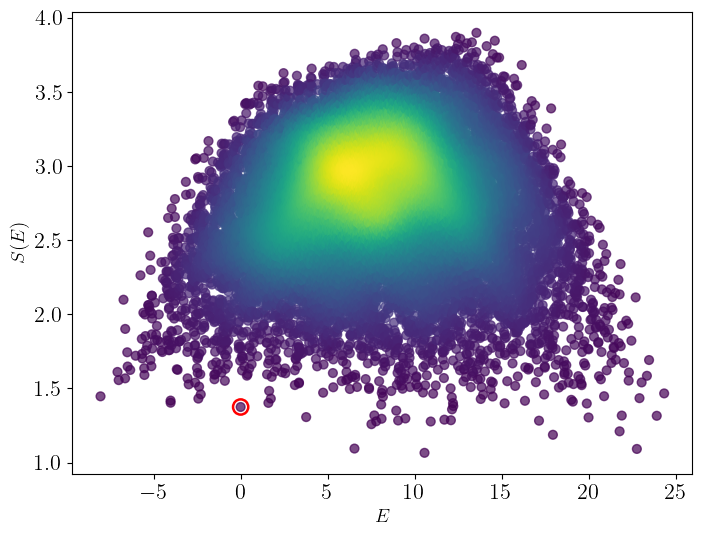

In [29]:
from scipy.stats import gaussian_kde
# Calculate point density for the entire plot area
xy = np.vstack([sorted_energies, sorted_entropies])
density = gaussian_kde(xy)(xy)

# Plotting
plt.figure(figsize=(8, 6), dpi=100)
plt.scatter(sorted_energies, sorted_entropies, c=density, s=40, cmap='viridis', alpha=0.7)

# Scar states
plt.scatter(
    sorted_energies[scars_idx],
    sorted_entropies[scars_idx],
    facecolors='none',
    edgecolors='red',
    marker='o',
    s=120,
    linewidths=1.8,
    label='Scar states',
    zorder=3
)

# Labels and title with LaTeX formatting
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$S(E)$", fontsize=14)

plt.grid(False)
#plt.savefig("Entropy_k2_chain_1_defect_L14.pdf",bbox_inches="tight")
plt.show()